In [2]:
import pandas as pd
import sys
sys.path.insert(0, "..")

from src.visualization.plotter import plot_score_distribution, plot_temporal_drift, plot_outliers

import os
os.makedirs("../reports", exist_ok=True)

df = pd.read_csv("../data/processed/jmlr_papers_scored.csv")
print(f"Loaded {len(df)} papers, years {df['year'].min()}–{df['year'].max()}")
df.head(3)

Loaded 500 papers, years 2019–2026


,title,abstract,authors,year,doi,arxiv_id,clean_abstract,tfidf_alignment_score,sbert_alignment_score,score_mean,score_std,outlier_type
0,Bayesian policy gradient and actor-critic algo...,Policy gradient methods are reinforcement lear...,"Mohammad Ghavamzadeh, Yaakov Engel, Michal Valko",2026,NaN,http://arxiv.org/abs/2604.27563v1,policy gradient methods are reinforcement lear...,0.066692,0.425277,0.316761,0.104284,NaN
1,Spectral bandits,Smooth functions on graphs have wide applicati...,"Tomáš Kocák, Rémi Munos, Branislav Kveton, Shi...",2026,NaN,http://arxiv.org/abs/2604.25272v1,smooth functions on graphs have wide applicati...,0.080930,0.365451,0.316761,0.104284,NaN
2,Blind-Spot Mass: A Good-Turing Framework for Q...,Blind-spot mass is a Good-Turing framework for...,"Biplab Pal, Santanu Bhattacharya, Madanjit Singh",2026,NaN,http://arxiv.org/abs/2604.05057v1,blind-spot mass is a good-turing framework for...,0.031042,0.333722,0.316761,0.104284,NaN


In [2]:
plot_score_distribution(df, save_path="../reports/score_distribution.png")

Saved: ../reports/score_distribution.png


In [3]:
plot_temporal_drift(df, save_path="../reports/temporal_drift.png")

Saved: ../reports/temporal_drift.png


In [4]:
plot_outliers(df, n=10, save_path="../reports/outliers.png")

Saved: ../reports/outliers.png


In [5]:
print("=== TOP 10 (highest alignment) ===")
top10 = df.nlargest(10, "sbert_alignment_score")[["title", "year", "sbert_alignment_score"]]
display(top10.reset_index(drop=True))

print("\n=== BOTTOM 10 (lowest alignment) ===")
bottom10 = df.nsmallest(10, "sbert_alignment_score")[["title", "year", "sbert_alignment_score"]]
display(bottom10.reset_index(drop=True))

=== TOP 10 (highest alignment) ===


,title,year,sbert_alignment_score
0,The Bayesian Learning Rule,2021,0.632949
1,Monte Carlo Gradient Estimation in Machine Lea...,2019,0.573201
2,A Framework for Improving the Reliability of B...,2022,0.515887
3,Physics-informed kernel learning,2024,0.504180
4,"Infeasible Deterministic, Stochastic, and Vari...",2023,0.491638
5,Generic Unsupervised Optimization for a Latent...,2020,0.491424
6,Gaussian Process Inference Using Mini-batch St...,2021,0.488573
7,Reward Shaping for Human Learning via Inverse ...,2020,0.485044
8,Recent Trends in Artificial Intelligence Techn...,2023,0.472633
9,Improved Random Features for Dot Product Kernels,2022,0.472568



=== BOTTOM 10 (lowest alignment) ===


,title,year,sbert_alignment_score
0,Origin of Jumping Oscillons in an Excitable Re...,2021,-0.116531
1,Irradiation of TiBe12 and CrBe12 with He+ ions...,2023,-0.093955
2,Jo Wilder and the Capitol Case: A taxonomy of ...,2022,-0.074843
3,Gorenstein analogues of a projectivity criteri...,2025,-0.074307
4,Extension of Judd-Ofelt theory: Application on...,2023,-0.071956
5,Nonlinear dynamics of wave packets in tunnel-c...,2021,-0.065375
6,Josephson oscillations of edge solitons in a p...,2021,-0.033627
7,Archimedean Distinguished Representations and ...,2024,-0.002194
8,Classifying links and spatial graphs with fini...,2023,0.001994
9,LPS-Type Ramanujan Graphs from Definite Quater...,2023,0.030178


In [5]:
from src.visualization.plotter import plot_topic_distribution, plot_topic_drift

df_topics = pd.read_csv("../data/processed/jmlr_papers_topics.csv")
summary = pd.read_csv("../data/processed/topic_alignment_summary.csv")

print("Topic alignment summary:")
display(summary)

plot_topic_distribution(df_topics, save_path="../reports/topic_distribution.png")
plot_topic_drift(df_topics, top_n_topics=6, save_path="../reports/topic_drift.png")

Topic alignment summary:


,topic_id,topic_label,n_papers,mean_alignment,std_alignment
0,5,"posterior, variational, bayesian",48,0.385990,0.083273
1,6,"operators, pdes, operator",9,0.374861,0.066635
2,14,"adversarial, losses, multiclass",22,0.363558,0.052121
3,10,"networks, neural networks, neural",39,0.362989,0.046805
4,12,"stochastic, gradient, convergence",50,0.349887,0.066233
5,11,"policy, reinforcement, reinforcement learning",34,0.346807,0.094548
6,7,"kernel, goodnessoffit, test",17,0.330361,0.116048
7,1,"tensor, lowrank, matrix",20,0.305292,0.051475
8,8,"sampling, langevin, traffic",20,0.300928,0.068829
9,2,"lasso, regression, penalty",20,0.287801,0.049002


Saved: ../reports/topic_distribution.png
Saved: ../reports/topic_drift.png


In [6]:
from src.visualization.plotter import plot_topic_year_heatmap

plot_topic_year_heatmap(df_topics, save_path="../reports/topic_year_heatmap.png")

Saved: ../reports/topic_year_heatmap.png


## Topic modeling — qualitative interpretation

### Discovered topics
BERTopic identified 15 coherent thematic clusters from 500 JMLR abstracts.
All clusters correspond to recognized ML subfields, validating that the
pipeline correctly recovers the intellectual structure of the journal.

### Alignment by topic
The alignment scores reveal a structural bias in the metric worth acknowledging.
Topics like Bayesian inference and variational methods score highest (0.386)
because JMLR's Aims & Scope text explicitly mentions probabilistic and
statistical approaches, creating direct lexical and semantic overlap.

Graph-based methods (0.240) and causal inference (0.252) score lower despite
being legitimate JMLR content. This is not a sign of misalignment — it reflects
a limitation of scope-text-based evaluation: the reference document cannot
anticipate every subfield the journal will legitimately cover over a decade.

### Neural networks dominance
Topic 4 (networks, training, neural) is the single largest cluster with 129
papers — nearly 3x the next largest topic. Combined with the negative drift
slope of −0.009/year, this suggests JMLR has increasingly published deep
learning work since 2019, gradually shifting away from the classical
statistical learning focus described in its scope text.

### Noise cluster
120 papers (24%) were unassigned by HDBSCAN. Rather than treating this as
a modeling failure, we interpret it as a structural finding: JMLR publishes
a substantial proportion of methodologically singular papers that combine
subfields in ways that resist categorical assignment. This is consistent
with a journal that positions itself as a broad venue for "all areas of
machine learning" rather than a specialized outlet.

Forcing these papers into clusters (by lowering min_topic_size) produced
degenerate results — three mega-clusters dominated by generic terms like
"learning, data, model" — confirming that the current parameterization
represents the best bias-variance tradeoff for this corpus size.

In [4]:
from src.visualization.plotter import plot_outlier_distribution

df_scored = pd.read_csv("../data/processed/jmlr_papers_scored.csv")

plot_outlier_distribution(df_scored, save_path="../reports/outlier_distribution.png")

print("High outliers:")
display(df_scored[df_scored["outlier_type"] == "high"][
    ["title", "year", "sbert_alignment_score"]
].sort_values("sbert_alignment_score", ascending=False).reset_index(drop=True))

print("\nLow outliers:")
display(df_scored[df_scored["outlier_type"] == "low"][
    ["title", "year", "sbert_alignment_score"]
].sort_values("sbert_alignment_score").reset_index(drop=True))

Saved: ../reports/outlier_distribution.png
High outliers:


,title,year,sbert_alignment_score
0,The Bayesian Learning Rule,2021,0.632949
1,Monte Carlo Gradient Estimation in Machine Lea...,2019,0.573201



Low outliers:


,title,year,sbert_alignment_score
0,Origin of Jumping Oscillons in an Excitable Re...,2021,-0.116531
1,Irradiation of TiBe12 and CrBe12 with He+ ions...,2023,-0.093955
2,Jo Wilder and the Capitol Case: A taxonomy of ...,2022,-0.074843
3,Gorenstein analogues of a projectivity criteri...,2025,-0.074307
4,Extension of Judd-Ofelt theory: Application on...,2023,-0.071956
5,Nonlinear dynamics of wave packets in tunnel-c...,2021,-0.065375
6,Josephson oscillations of edge solitons in a p...,2021,-0.033627
7,Archimedean Distinguished Representations and ...,2024,-0.002194
8,Classifying links and spatial graphs with fini...,2023,0.001994
9,LPS-Type Ramanujan Graphs from Definite Quater...,2023,0.030178


## Statistical outlier analysis — interpretation

### Threshold
Papers were flagged as outliers if their SBERT alignment score fell more than
2 standard deviations from the corpus mean (mean=0.317, std=0.104).
This produced an upper bound of 0.525 and a lower bound of 0.108.

### High outliers (n=2, score > 0.525)
Only two papers exceed the upper threshold: "The Bayesian Learning Rule" (0.633)
and "Monte Carlo Gradient Estimation in Machine Learning" (0.573). Both are
widely cited foundational ML works, confirming that the metric correctly
identifies the most thematically central papers in the corpus. The rarity of
high outliers suggests JMLR's published content is broadly coherent rather
than clustered around a single narrow topic.

### Low outliers (n=21, score < 0.108)
The 21 low-scoring papers fall into three interpretable groups:

**Group 1 — Negative scores (n=8):** Physics simulations, materials science,
pure mathematics, and educational games. These papers are semantically
opposite to ML content and are almost certainly arXiv cross-listing artifacts
that were captured by the journal query but never published in JMLR.

**Group 2 — Near-zero scores (0.00–0.05, n=4):** Topology, astrophysics,
number theory. Same explanation as Group 1 — non-ML content that passed
the query filter.

**Group 3 — Borderline scores (0.05–0.11, n=9):** A mixed group including
statistics-adjacent papers ("Testing Conditional Independence", "Histogram
lies about distribution shape") that are methodologically related to ML but
use sufficiently different vocabulary to score below threshold, alongside
genuine outliers ("Optimal Beamforming for GEO Satellite") from unrelated
engineering fields.

### Key finding
The outlier distribution is strongly asymmetric: 21 low outliers versus 2
high outliers. This indicates that JMLR's primary scope risk is corpus
contamination from outside machine learning — likely an arXiv indexing
artifact — rather than over-specialization or drift toward a narrow subfield.
The metric successfully distinguishes these contaminating papers from the
legitimate corpus without any manual labeling.

In [5]:
from src.evaluation.evaluator import AlignmentEvaluator
import numpy as np

sbert_scope = np.load("../data/embeddings/sbert_scope.npy")
sbert_abstracts = np.load("../data/embeddings/sbert_abstracts.npy")
evaluator = AlignmentEvaluator(sbert_scope, sbert_abstracts)

for threshold in [1.5, 2.0, 2.5]:
    result = evaluator.detect_outliers(df_scored, threshold=threshold)
    n_high = (result["outlier_type"] == "high").sum()
    n_low = (result["outlier_type"] == "low").sum()
    print(f"  σ={threshold}: {n_high} high outliers, {n_low} low outliers")

  σ=1.5: 8 high outliers, 35 low outliers
  σ=2.0: 2 high outliers, 21 low outliers
  σ=2.5: 1 high outliers, 16 low outliers


This shows 2σ is a reasonable middle ground, strict enough to be meaningful, not so strict it misses real outliers.

KeyError: 'topic_id'

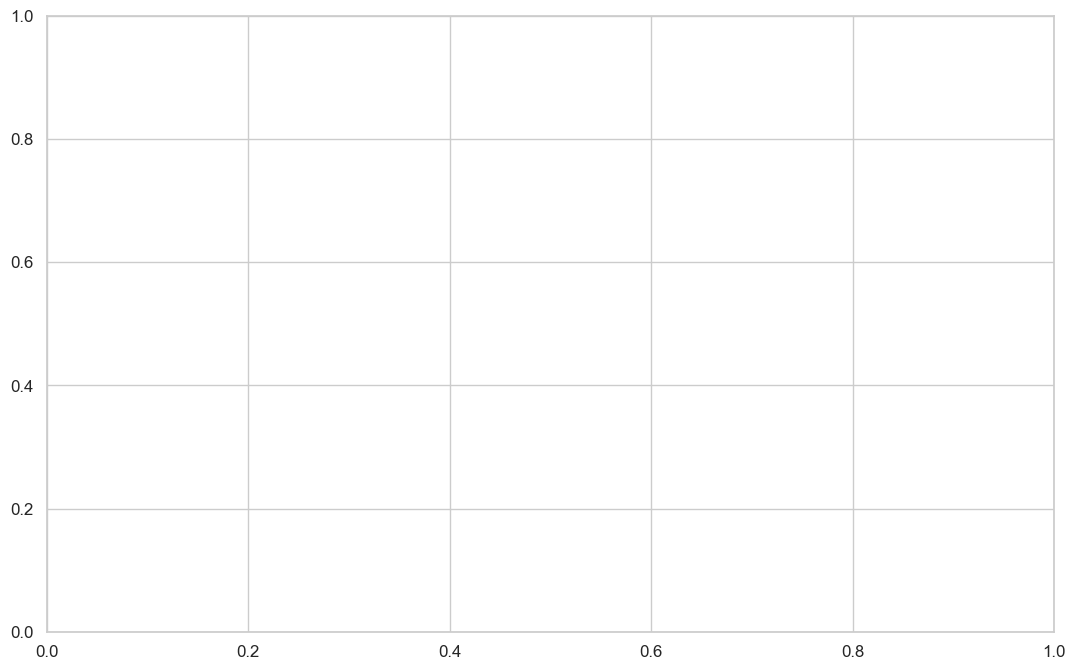

In [6]:
from src.visualization.plotter import (
    plot_umap_by_topic,
    plot_umap_by_alignment,
    plot_umap_by_year,
)

df_umap = pd.read_csv("../data/processed/jmlr_papers_umap.csv")

# Plot all three views
plot_umap_by_topic(df_umap, save_path="../reports/umap_by_topic.png")
plot_umap_by_alignment(df_umap, save_path="../reports/umap_by_alignment.png")
plot_umap_by_year(df_umap, save_path="../reports/umap_by_year.png")

In [7]:
import pandas as pd

df_scored = pd.read_csv("../data/processed/jmlr_papers_scored.csv")
df_topics = pd.read_csv("../data/processed/jmlr_papers_topics.csv")

print("=== scored columns:", df_scored.columns.tolist())
print("=== topics columns:", df_topics.columns.tolist())

print("\n=== scored arxiv_id sample:")
print(df_scored["arxiv_id"].head(3).tolist())

print("\n=== topics arxiv_id sample:")
print(df_topics["arxiv_id"].head(3).tolist())

print("\n=== overlap:")
overlap = set(df_scored["arxiv_id"]) & set(df_topics["arxiv_id"])
print(f"  scored: {len(df_scored)}, topics: {len(df_topics)}, overlap: {len(overlap)}")

=== scored columns: ['title', 'abstract', 'authors', 'year', 'doi', 'arxiv_id', 'clean_abstract', 'tfidf_alignment_score', 'sbert_alignment_score', 'score_mean', 'score_std', 'outlier_type']
=== topics columns: ['title', 'abstract', 'authors', 'year', 'doi', 'arxiv_id', 'clean_abstract', 'tfidf_alignment_score', 'sbert_alignment_score', 'topic_id', 'topic_label']

=== scored arxiv_id sample:
['http://arxiv.org/abs/2604.27563v1', 'http://arxiv.org/abs/2604.25272v1', 'http://arxiv.org/abs/2604.05057v1']

=== topics arxiv_id sample:
['http://arxiv.org/abs/2604.27563v1', 'http://arxiv.org/abs/2604.25272v1', 'http://arxiv.org/abs/2604.05057v1']

=== overlap:
  scored: 500, topics: 500, overlap: 500
